In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

transactions_clean = pd.read_csv("clean_data/transactions_clean.csv", parse_dates=["invoice_date"])
customers_clean    = pd.read_csv("clean_data/customers_clean.csv")

print("Données chargées ✓")

Données chargées ✓


In [69]:
print("\n\n------------------------------------------------ ETAPE 1.a : Construction des features RFM ----------------------------------------------")
print("\n1) À partir de transactions.csv nettoyé, calculez pour chaque client Recence / fréquence / montant")

# La snapshot date = date max du dataset (pas la date du jour)
snapshot_date = transactions_clean["invoice_date"].max()
print(f"\nSnapshot date : {snapshot_date.date()}")

print("\n====== CALCUL RFM ======")
rfm = transactions_clean.groupby("customer_id").agg(
    recence   = ("invoice_date", lambda dates: (snapshot_date - dates.max()).days),
    frequence = ("invoice_id",   "nunique"),
    montant   = ("line_total",   "sum")
).reset_index()
print(f"\nNombre de clients dans la table RFM : {len(rfm)}")
print("\nAperçu :")
print(rfm.head(20).to_string(index=False))

print("\n====== TOP 15 PAR RÉCENCE (plus récent → moins récent) ======")
print(rfm.sort_values("recence",
ascending=True).head(15).to_string(index=False))

print("\n====== TOP 15 PAR FRÉQUENCE (plus fréquent → moins fréquent) ======")
print(rfm.sort_values("frequence",
ascending=False).head(15).to_string(index=False))

print("\n====== TOP 15 PAR MONTANT (plus gros → plus petit) ======")
print(rfm.sort_values("montant",
ascending=False).head(15).to_string(index=False))

print("\n====== FEATURES SUPPLEMENTAIRES ======")
print("--> Ajout du panier moyen et de l'ancienneté (tenure)")
rfm["panier_moyen"] = rfm["montant"] / rfm["frequence"]

customers_clean["first_purchase"] = pd.to_datetime(customers_clean["first_purchase"])
anciennete = customers_clean[["customer_id", "first_purchase"]].copy()
anciennete["anciennete_jours"] = (snapshot_date - anciennete["first_purchase"]).dt.days
rfm = rfm.merge(anciennete[["customer_id", "anciennete_jours"]], on="customer_id", how="left")

print("\nStatistiques :")
print(rfm[["recence", "frequence", "montant", "panier_moyen", "anciennete_jours"]].describe().round(1))



------------------------------------------------ ETAPE 1.a : Construction des features RFM ----------------------------------------------

1) À partir de transactions.csv nettoyé, calculez pour chaque client Recence / fréquence / montant

Snapshot date : 2026-06-30

====== CALCUL RFM ======

Nombre de clients dans la table RFM : 48530

Aperçu :
 customer_id  recence  frequence  montant
     12346.0      325         12   711.26
     12347.0        1          8  7740.74
     12348.0       74          5  1537.84
     12349.0       18          3  5423.50
     12350.0      309          1   549.89
     12351.0      374          1   632.28
     12352.0       35          9  3169.73
     12353.0      203          2   780.89
     12354.0      231          1  2125.84
     12355.0      213          2  1137.54
     12356.0       22          6  4120.90
     12358.0        1          5  2252.85
     12360.0       51          6  6483.14
     12361.0      286          4  1179.56
     12362.0        2

In [71]:
print("\n\n------------------------------------------------ ETAPE 1.b : Scoring RFM par saison ----------------------------------------------")

# Définition des saisons
saisons = {
    "Q1_janv_mars" : [1, 2, 3],
    "Q2_avr_juin"  : [4, 5, 6],
    "Q3_juil_sept" : [7, 8, 9],
    "Q4_oct_dec"   : [10, 11, 12]
}

transactions_clean["mois"] = transactions_clean["invoice_date"].dt.month

rfm_saisons = {}

for nom_saison, mois in saisons.items():
    print(f"\n====== {nom_saison} ======")

    # Filtrer les transactions de la saison
    tx_saison = transactions_clean[transactions_clean["mois"].isin(mois)].copy()

    # Date de fin de saison = dernier jour du dernier mois de la saison
    snapshot_saison = tx_saison["invoice_date"].max()

    # Calcul RFM pour cette saison
    rfm_s = tx_saison.groupby("customer_id").agg(
        recence   = ("invoice_date", lambda dates: (snapshot_saison - dates.max()).days),
        frequence = ("invoice_id",   "nunique"),
        montant   = ("line_total",   "sum")
    ).reset_index()

    # Scoring par quintiles (rang)
    rfm_s["score_R"] = pd.qcut(rfm_s["recence"],   q=5, labels=[5, 4, 3, 2, 1])
    rfm_s["score_F"] = pd.qcut(rfm_s["frequence"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5])
    rfm_s["score_M"] = pd.qcut(rfm_s["montant"].rank(method="first"),   q=5, labels=[1, 2, 3, 4, 5])

    rfm_s["score_RFM"] = rfm_s["score_R"].astype(str) + rfm_s["score_F"].astype(str) + rfm_s["score_M"].astype(str)
    rfm_s["saison"]    = nom_saison

    print(f"Clients actifs : {len(rfm_s)}")
    print(rfm_s[["customer_id", "recence", "frequence", "montant", "score_R", "score_F", "score_M", "score_RFM"]].head(10).to_string(index=False))

    rfm_saisons[nom_saison] = rfm_s

# Table complète toutes saisons
rfm_all_saisons = pd.concat(rfm_saisons.values(), ignore_index=True)
print(f"\nTable RFM toutes saisons : {len(rfm_all_saisons)} lignes")
print(rfm_all_saisons.groupby("saison")["customer_id"].count())



------------------------------------------------ ETAPE 1.b : Scoring RFM par saison ----------------------------------------------

====== Q1_janv_mars ======
Clients actifs : 26787
 customer_id  recence  frequence  montant score_R score_F score_M score_RFM
     12346.0      438          1   520.28       1       1       5       115
     12347.0       38          1   660.44       4       1       5       415
     12358.0       59          1   367.10       3       1       5       315
     12360.0       21          1   906.11       4       1       5       415
     12361.0      371          1   236.48       2       1       4       214
     12362.0       29          2  1043.06       4       3       5       435
     12363.0       18          1   194.38       5       1       4       514
     12364.0       21          1   807.78       4       1       5       415
     12375.0        7          1   392.88       5       1       5       515
     12379.0       78          2   913.60       3       

In [72]:
print("\n\n------------------------------------------------ ETAPE 2 : Labellisation des segments RFM ----------------------------------------------")

# Labels connus
labels_connus = {
    "555" : "Champions",
    "511" : "Nouveaux prometteurs",
    "155" : "À risque",
    "111" : "Perdus",
    "333" : "Clients moyens"
}

rfm_all_saisons["segment"] = rfm_all_saisons["score_RFM"].map(labels_connus).fillna("Non labellisé")

print("\n====== RÉPARTITION DES SEGMENTS CONNUS ======")
segments_connus = rfm_all_saisons[rfm_all_saisons["segment"] != "Non labellisé"]
print(segments_connus.groupby(["saison", "segment"])["customer_id"].count().to_string())

print("\n====== SCORES NON LABELLISÉS — répartition par proportion ======")
non_labelises = rfm_all_saisons[rfm_all_saisons["segment"] == "Non labellisé"]
distribution = (
    non_labelises.groupby("score_RFM")["customer_id"]
    .count()
    .reset_index()
    .rename(columns={"customer_id": "nb_clients"})
    .sort_values("nb_clients", ascending=False)
)
distribution["pct"] = (distribution["nb_clients"] / len(rfm_all_saisons) * 100).round(2)
print(distribution.to_string(index=False))



------------------------------------------------ ETAPE 2 : Labellisation des segments RFM ----------------------------------------------

====== RÉPARTITION DES SEGMENTS CONNUS ======
saison        segment             
Q1_janv_mars  Champions               1327
              Clients moyens           262
              Nouveaux prometteurs     114
              Perdus                   678
              À risque                  58
Q2_avr_juin   Champions               1652
              Clients moyens           265
              Nouveaux prometteurs      62
              Perdus                   808
              À risque                  68
Q3_juil_sept  Champions                994
              Clients moyens           175
              Nouveaux prometteurs     157
              Perdus                   440
              À risque                  59
Q4_oct_dec    Champions               1205
              Clients moyens           202
              Nouveaux prometteurs     160
     

In [73]:
print("\n====== RÈGLE ±1 POINT : assignation des scores proches ======")
print("--> Si un score est à 1 point de distance d'un segment connu, on l'y rattache")

non_labelises_avant = (rfm_all_saisons["segment"] == "Non labellisé").sum()
print(f"\nNon labellisés AVANT règle ±1 : {non_labelises_avant} ({non_labelises_avant/len(rfm_all_saisons)*100:.1f}%)")

def distance_rfm(score_a, score_b):
    return sum(abs(int(a) - int(b)) for a, b in zip(score_a, score_b))

def assigner_segment(score_rfm):
    if score_rfm in labels_connus:
        return labels_connus[score_rfm]
    candidats = {label: distance_rfm(score_rfm, score)
                 for score, label in labels_connus.items()}
    min_distance = min(candidats.values())
    if min_distance == 1:
        return min(candidats, key=candidats.get)
    return "Non labellisé"

rfm_all_saisons["segment_v2"] = rfm_all_saisons["score_RFM"].apply(assigner_segment)

non_labelises_apres = (rfm_all_saisons["segment_v2"] == "Non labellisé").sum()
print(f"Non labellisés APRÈS règle ±1 : {non_labelises_apres} ({non_labelises_apres/len(rfm_all_saisons)*100:.1f}%)")
print(f"Récupérés par la règle        : {non_labelises_avant - non_labelises_apres} clients")

recap = (
    rfm_all_saisons.groupby("segment_v2")["customer_id"]
    .count()
    .reset_index()
    .rename(columns={"customer_id": "nb_clients"})
    .sort_values("nb_clients", ascending=False)
)
recap["pct"] = (recap["nb_clients"] / len(rfm_all_saisons) * 100).round(1)
print(f"\n{recap.to_string(index=False)}")


====== RÈGLE ±1 POINT : assignation des scores proches ======
--> Si un score est à 1 point de distance d'un segment connu, on l'y rattache

Non labellisés AVANT règle ±1 : 94523 (91.1%)
Non labellisés APRÈS règle ±1 : 73550 (70.9%)
Récupérés par la règle        : 20973 clients

          segment_v2  nb_clients  pct
       Non labellisé       73550 70.9
           Champions       11602 11.2
              Perdus        7982  7.7
      Clients moyens        6564  6.3
Nouveaux prometteurs        2392  2.3
            À risque        1680  1.6


In [82]:
print("\n====== SEGMENTATION FINALE — 3ème vague : règle métier sur scores R / F / M ======")

def segmenter(row):
    R, F, M = int(row["score_R"]), int(row["score_F"]), int(row["score_M"])
    if R >= 4 and F >= 4 and M >= 4:   return "Champions"
    if R >= 4 and F <= 2:              return "Nouveaux prometteurs"
    if R <= 2 and F >= 4 and M >= 4:   return "À risque"
    if R <= 2 and F <= 2 and M <= 2:   return "Perdus"
    if R >= 3 and F >= 3 and M >= 3:   return "Fidèles"
    if R <= 2:                         return "Hibernants"
    return "Clients moyens"

rfm_all_saisons["segment_v3"] = rfm_all_saisons.apply(
    lambda row: segmenter(row) if row["segment_v2"] == "Non labellisé" else row["segment_v2"],
    axis=1
)

recap_v3 = (
    rfm_all_saisons.groupby("segment_v3")["customer_id"]
    .count()
    .reset_index()
    .rename(columns={"customer_id": "nb_clients"})
    .sort_values("nb_clients", ascending=False)
)
recap_v3["pct"] = (recap_v3["nb_clients"] / len(rfm_all_saisons) * 100).round(1)

print(recap_v3.to_string(index=False))


====== SEGMENTATION FINALE — 3ème vague : règle métier sur scores R / F / M ======
          segment_v3  nb_clients  pct
      Clients moyens       21656 20.9
          Hibernants       20994 20.2
           Champions       17575 16.9
              Perdus       14344 13.8
             Fidèles       13735 13.2
Nouveaux prometteurs       10305  9.9
            À risque        5161  5.0



====== RÉPARTITION DES SEGMENTS PAR SAISON — 2026 ======
saison                Q1 Jan-Mar  Q2 Avr-Jun
segment                                     
Champions                   15.5        16.2
Clients moyens              17.7        19.0
Fidèles                     16.7        17.1
Hibernants                  22.0        21.6
Nouveaux prometteurs        11.0         8.2
Perdus                      12.2        14.2
À risque                     4.9         3.7


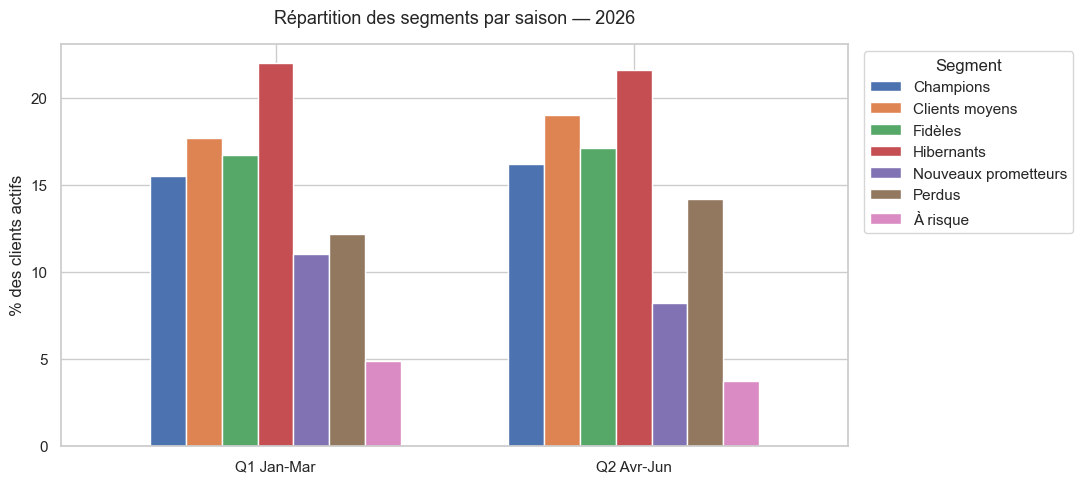

In [83]:
print("\n====== RÉPARTITION DES SEGMENTS PAR SAISON — 2026 ======")

saisons_2026 = {
    "Q1 Jan-Mar" : [1, 2, 3],
    "Q2 Avr-Jun" : [4, 5, 6],
}

tx_2026 = transactions_clean[transactions_clean["invoice_date"].dt.year == 2026].copy()

rfm_2026_saisons = []

for nom_saison, mois in saisons_2026.items():
    tx_s = tx_2026[tx_2026["invoice_date"].dt.month.isin(mois)]
    if len(tx_s) == 0:
        continue
    snapshot_s = tx_s["invoice_date"].max()

    rfm_s = tx_s.groupby("customer_id").agg(
        recence   = ("invoice_date", lambda dates: (snapshot_s - dates.max()).days),
        frequence = ("invoice_id",   "nunique"),
        montant   = ("line_total",   "sum")
    ).reset_index()

    rfm_s["score_R"] = pd.qcut(rfm_s["recence"],                        q=5, labels=[5, 4, 3, 2, 1])
    rfm_s["score_F"] = pd.qcut(rfm_s["frequence"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5])
    rfm_s["score_M"] = pd.qcut(rfm_s["montant"].rank(method="first"),   q=5, labels=[1, 2, 3, 4, 5])

    rfm_s["segment"] = rfm_s.apply(segmenter, axis=1)
    rfm_s["saison"]  = nom_saison
    rfm_2026_saisons.append(rfm_s)

rfm_2026_all = pd.concat(rfm_2026_saisons, ignore_index=True)

repartition_2026 = (
    rfm_2026_all.groupby(["saison", "segment"])["customer_id"]
    .count()
    .reset_index()
    .rename(columns={"customer_id": "nb_clients"})
)

total_par_saison_2026 = rfm_2026_all.groupby("saison")["customer_id"].count()
repartition_2026["pct"] = repartition_2026.apply(
    lambda row: round(row["nb_clients"] / total_par_saison_2026[row["saison"]] * 100, 1), axis=1
)

pivot_2026 = repartition_2026.pivot(index="segment", columns="saison", values="pct").fillna(0)
print(pivot_2026.to_string())

fig, ax = plt.subplots(figsize=(11, 5))
pivot_2026.T.plot(kind="bar", ax=ax, width=0.7)

ax.set_title("Répartition des segments par saison — 2026", fontsize=13, pad=15)
ax.set_xlabel("")
ax.set_ylabel("% des clients actifs")
ax.set_xticklabels(list(saisons_2026.keys()), rotation=0)
ax.legend(title="Segment", bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.show()


====== TOP 10 PRODUITS AU PRINTEMPS (Q2) — 2022 à 2026 ======
annee                                   2022   2023  2024   2025   2026
product_name                                                           
Beurre Corporel Cacao Karité            4.54   6.25  4.93   4.76   4.93
Coffret Duo Visage Bio                 16.71   9.58  9.35  10.51  10.31
Coffret Découverte Rituel Slow Beauty   9.17  12.44  9.89   9.24   9.96
Contour des Yeux Concombre              7.02   6.08  6.51   6.58   5.89
Crème Jour Karité Vanille               2.28   6.76  6.12   6.76   5.90
Gommage Corps Sucre Coco                4.10   3.39  4.34   4.14   4.42
Huile Capillaire Ricin Bio              9.19   3.64  3.76   3.90   3.76
Huile Sèche Corps Monoï                 4.77   4.34  5.55   4.77   5.14
Lait Corps Amande Douce                 6.28   4.27  4.00   3.75   4.00
Sérum Visage Bio Rose Musquée           9.71   8.02  8.84   8.08   7.14


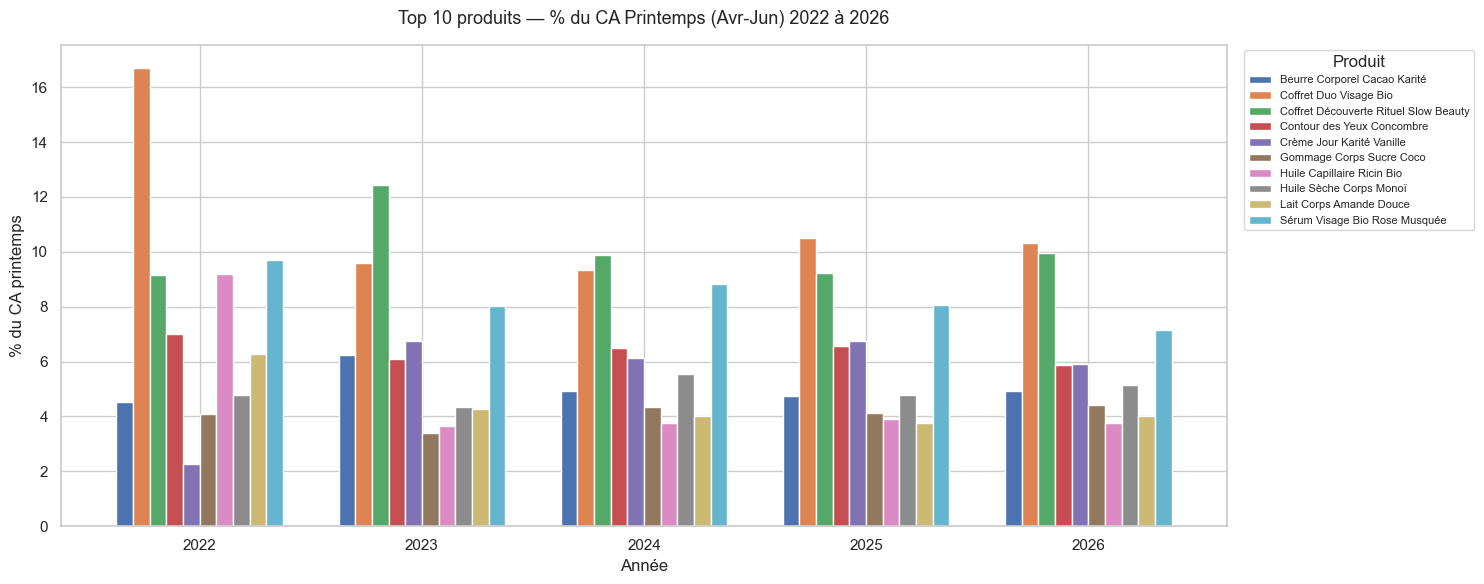

In [91]:
print("\n====== TOP 10 PRODUITS AU PRINTEMPS (Q2) — 2022 à 2026 ======")

ca_produit = (
    tx_printemps.groupby(["annee", "product_name"])["line_total"]
    .sum()
    .reset_index()
    .rename(columns={"line_total": "ca"})
)

total_par_annee_prod = ca_produit.groupby("annee")["ca"].transform("sum")
ca_produit["pct"] = (ca_produit["ca"] / total_par_annee_prod * 100).round(2)

top10_produits = (
    ca_produit.groupby("product_name")["ca"]
    .sum()
    .nlargest(10)
    .index.tolist()
)

ca_produit_top10 = ca_produit[ca_produit["product_name"].isin(top10_produits)]
pivot_prod = ca_produit_top10.pivot(index="product_name", columns="annee", values="pct").fillna(0)
print(pivot_prod.to_string())

fig, ax = plt.subplots(figsize=(15, 6))
pivot_prod.T.plot(kind="bar", ax=ax, width=0.75)

ax.set_title("Top 10 produits — % du CA Printemps (Avr-Jun) 2022 à 2026", fontsize=13, pad=15)
ax.set_xlabel("Année")
ax.set_ylabel("% du CA printemps")
ax.set_xticklabels([str(a) for a in sorted(tx_printemps["annee"].unique())], rotation=0)
ax.legend(title="Produit", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()


====== CA PAR SAISON ET PAR ANNÉE ======


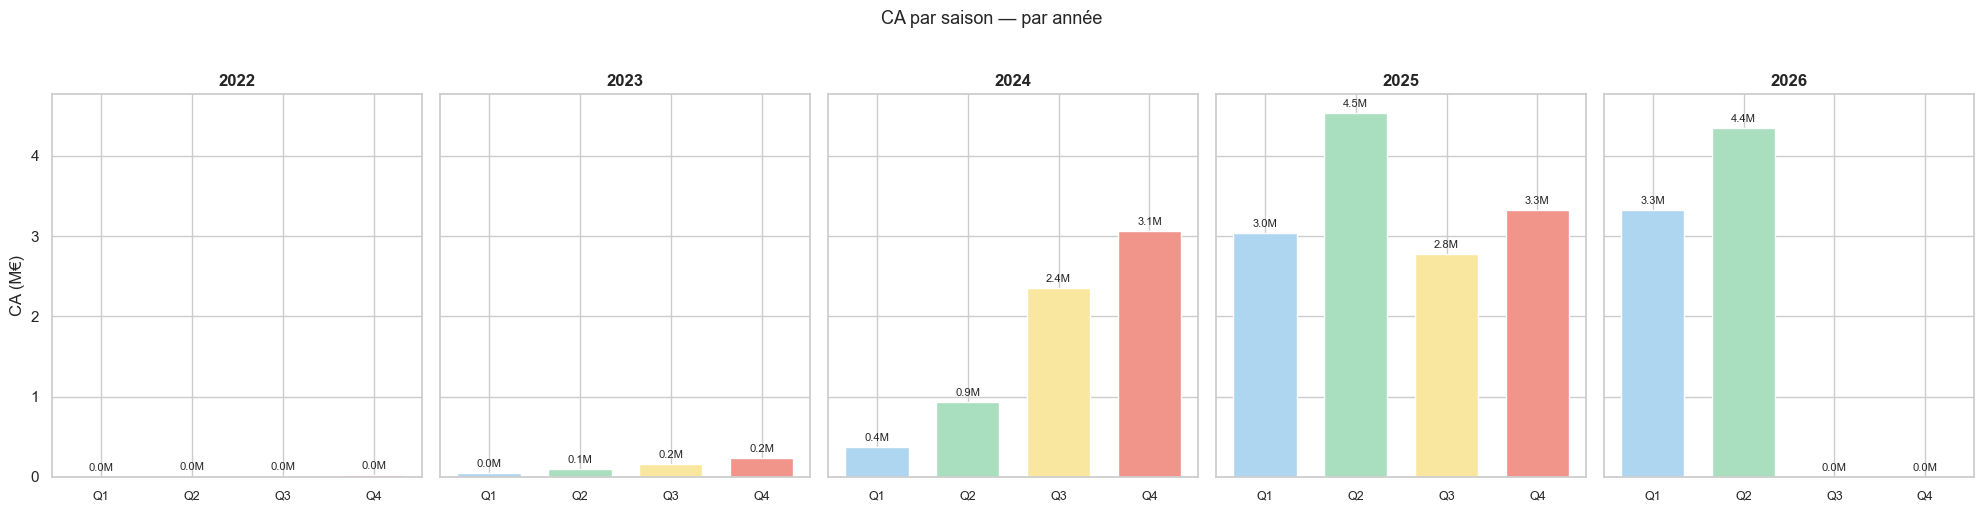

In [97]:
print("\n====== CA PAR SAISON ET PAR ANNÉE ======")

saisons_mois = {
    "Q1 Jan-Mar" : [1, 2, 3],
    "Q2 Avr-Jun" : [4, 5, 6],
    "Q3 Jul-Sep" : [7, 8, 9],
    "Q4 Oct-Déc" : [10, 11, 12],
}

transactions_clean["annee"] = transactions_clean["invoice_date"].dt.year
transactions_clean["saison_label"] = transactions_clean["invoice_date"].dt.month.map(
    {m: nom for nom, mois in saisons_mois.items() for m in mois}
)

ca_annee_saison = (
    transactions_clean.groupby(["annee", "saison_label"])["line_total"]
    .sum()
    .reset_index()
    .rename(columns={"line_total": "ca"})
)

couleurs = ["#AED6F1", "#A9DFBF", "#F9E79F", "#F1948A"]
annees   = sorted(ca_annee_saison["annee"].unique())

fig, axes = plt.subplots(1, len(annees), figsize=(4 * len(annees), 5), sharey=True)

for ax, annee in zip(axes, annees):
    data = ca_annee_saison[ca_annee_saison["annee"] == annee].set_index("saison_label")
    data = data.reindex(list(saisons_mois.keys())).fillna(0)

    bars = ax.bar(range(len(data)), data["ca"] / 1e6, color=couleurs, edgecolor="white", width=0.7)

    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                f"{bar.get_height():.1f}M", ha="center", va="bottom", fontsize=8)

    ax.set_title(str(annee), fontsize=12, fontweight="bold")
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(["Q1", "Q2", "Q3", "Q4"], fontsize=9)
    ax.set_xlabel("")
    if ax == axes[0]:
        ax.set_ylabel("CA (M€)")

fig.suptitle("CA par saison — par année", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


====== TOP PRODUITS — AUTOMNE (Q4 Oct-Déc) 2024 ======


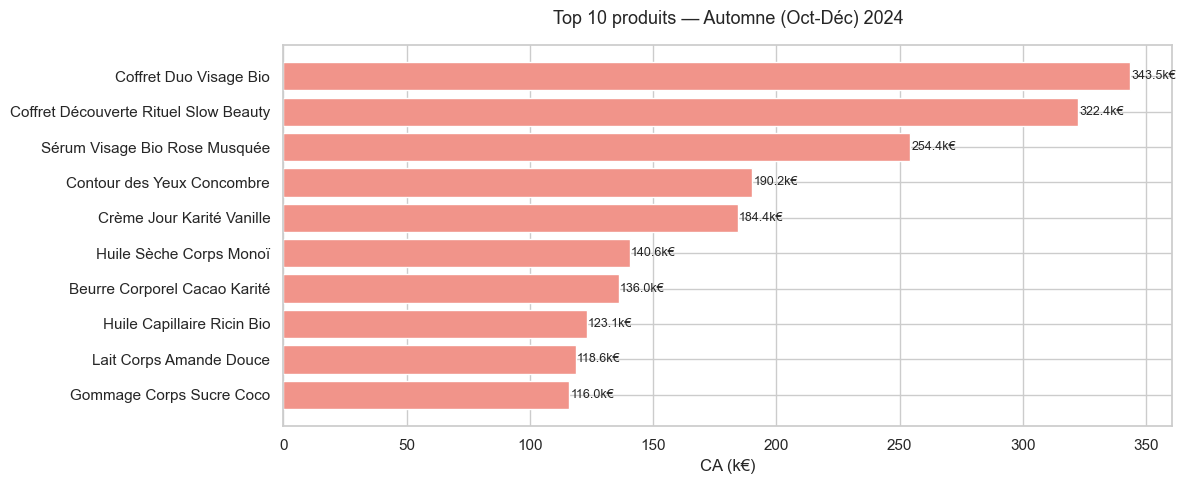

In [107]:
print("\n====== TOP PRODUITS — AUTOMNE (Q4 Oct-Déc) 2024 ======")

tx_automne_2024 = tx_2024[tx_2024["saison_label"] == "Q4 Oct-Déc"]

top_automne = (
    tx_automne_2024.groupby("product_name")["line_total"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={"line_total": "ca"})
)
top_automne["pct"] = (top_automne["ca"] / tx_automne_2024["line_total"].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top_automne["product_name"][::-1], top_automne["ca"][::-1] / 1e3,
               color="#F1948A", edgecolor="white")

for bar in bars:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.1f}k€", va="center", fontsize=9)

ax.set_title("Top 10 produits — Automne (Oct-Déc) 2024", fontsize=13, pad=15)
ax.set_xlabel("CA (k€)")
ax.set_ylabel("")

plt.tight_layout()
plt.show()


====== TOP PRODUITS — PRINTEMPS (Q2 Avr-Jun) 2025 ======


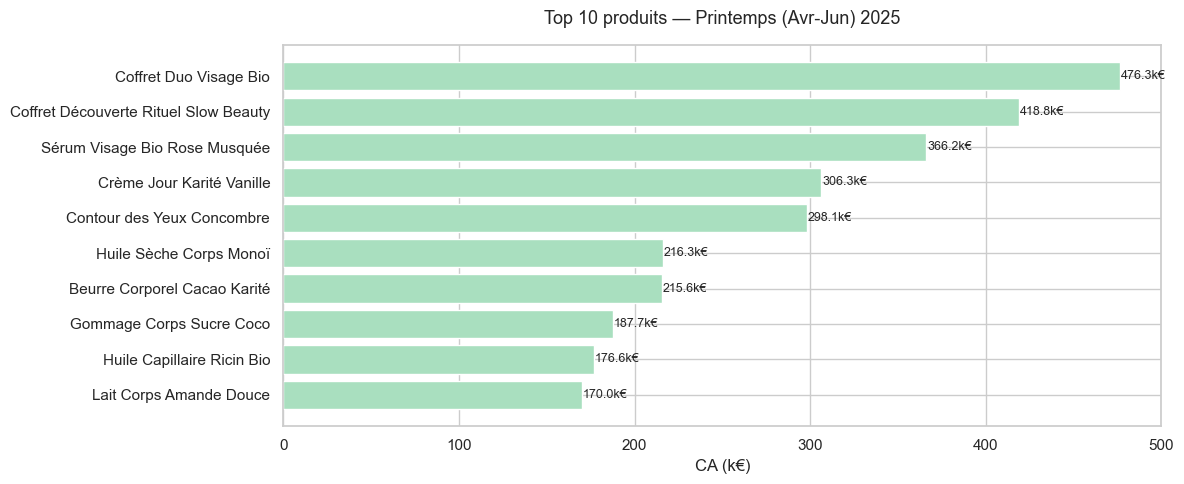

In [108]:
print("\n====== TOP PRODUITS — PRINTEMPS (Q2 Avr-Jun) 2025 ======")

tx_printemps_2025 = transactions_clean[
    (transactions_clean["invoice_date"].dt.year == 2025) &
    (transactions_clean["invoice_date"].dt.month.isin([4, 5, 6]))
]

top_printemps_2025 = (
    tx_printemps_2025.groupby("product_name")["line_total"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={"line_total": "ca"})
)
top_printemps_2025["pct"] = (top_printemps_2025["ca"] / tx_printemps_2025["line_total"].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top_printemps_2025["product_name"][::-1], top_printemps_2025["ca"][::-1] / 1e3,
               color="#A9DFBF", edgecolor="white")

for bar in bars:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.1f}k€", va="center", fontsize=9)

ax.set_title("Top 10 produits — Printemps (Avr-Jun) 2025", fontsize=13, pad=15)
ax.set_xlabel("CA (k€)")
ax.set_ylabel("")

plt.tight_layout()
plt.show()


====== TOP PRODUITS — PRINTEMPS (Q2 Avr-Jun) 2024 ======


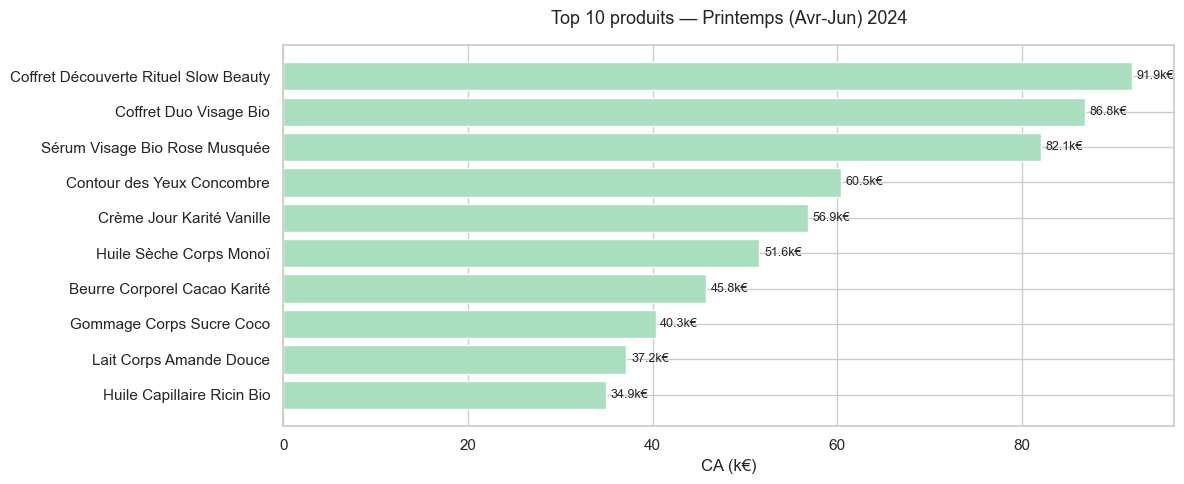

In [104]:
print("\n====== TOP PRODUITS — PRINTEMPS (Q2 Avr-Jun) 2024 ======")

tx_printemps_2024 = tx_2024[tx_2024["saison_label"] == "Q2 Avr-Jun"]

top_printemps_2024 = (
    tx_printemps_2024.groupby("product_name")["line_total"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={"line_total": "ca"})
)
top_printemps_2024["pct"] = (top_printemps_2024["ca"] / tx_printemps_2024["line_total"].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top_printemps_2024["product_name"][::-1], top_printemps_2024["ca"][::-1] / 1e3,
               color="#A9DFBF", edgecolor="white")

for bar in bars:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.1f}k€", va="center", fontsize=9)

ax.set_title("Top 10 produits — Printemps (Avr-Jun) 2024", fontsize=13, pad=15)
ax.set_xlabel("CA (k€)")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

In [ ]:
print("\n====== TOP PRODUITS — AUTOMNE (Q4 Oct-Déc) 2025 ======")

tx_automne_2025 = transactions_clean[
    (transactions_clean["invoice_date"].dt.year == 2025) &
    (transactions_clean["invoice_date"].dt.month.isin([10, 11, 12]))
]

top_automne_2025 = (
    tx_automne_2025.groupby("product_name")["line_total"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={"line_total": "ca"})
)
top_automne_2025["pct"] = (top_automne_2025["ca"] / tx_automne_2025["line_total"].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top_automne_2025["product_name"][::-1], top_automne_2025["ca"][::-1] / 1e3,
               color="#F1948A", edgecolor="white")

for bar in bars:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.1f}k€", va="center", fontsize=9)

ax.set_title("Top 10 produits — Automne (Oct-Déc) 2025", fontsize=13, pad=15)
ax.set_xlabel("CA (k€)")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

In [ ]:
print("\n====== RÉPARTITION DES SEGMENTS PAR SAISON — 2025 ======")

saisons_2025 = {
    "Q1 Jan-Mar" : [1, 2, 3],
    "Q2 Avr-Jun" : [4, 5, 6],
    "Q3 Jul-Sep" : [7, 8, 9],
    "Q4 Oct-Déc" : [10, 11, 12],
}

tx_2025 = transactions_clean[transactions_clean["invoice_date"].dt.year == 2025].copy()
rfm_2025_saisons = []

for nom_saison, mois in saisons_2025.items():
    tx_s = tx_2025[tx_2025["invoice_date"].dt.month.isin(mois)]
    if len(tx_s) == 0:
        continue
    snapshot_s = tx_s["invoice_date"].max()

    rfm_s = tx_s.groupby("customer_id").agg(
        recence   = ("invoice_date", lambda dates: (snapshot_s - dates.max()).days),
        frequence = ("invoice_id",   "nunique"),
        montant   = ("line_total",   "sum")
    ).reset_index()

    rfm_s["score_R"] = pd.qcut(rfm_s["recence"],                        q=5, labels=[5, 4, 3, 2, 1])
    rfm_s["score_F"] = pd.qcut(rfm_s["frequence"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5])
    rfm_s["score_M"] = pd.qcut(rfm_s["montant"].rank(method="first"),   q=5, labels=[1, 2, 3, 4, 5])

    rfm_s["segment"] = rfm_s.apply(segmenter, axis=1)
    rfm_s["saison"]  = nom_saison
    rfm_2025_saisons.append(rfm_s)

rfm_2025_all = pd.concat(rfm_2025_saisons, ignore_index=True)

repartition_2025 = (
    rfm_2025_all.groupby(["saison", "segment"])["customer_id"]
    .count()
    .reset_index()
    .rename(columns={"customer_id": "nb_clients"})
)

total_par_saison_2025 = rfm_2025_all.groupby("saison")["customer_id"].count()
repartition_2025["pct"] = repartition_2025.apply(
    lambda row: round(row["nb_clients"] / total_par_saison_2025[row["saison"]] * 100, 1), axis=1
)

pivot_2025 = repartition_2025.pivot(index="segment", columns="saison", values="pct").fillna(0)
pivot_2025 = pivot_2025[list(saisons_2025.keys())]

fig, ax = plt.subplots(figsize=(13, 5))
pivot_2025.T.plot(kind="bar", ax=ax, width=0.75)

ax.set_title("Répartition des segments par saison — 2025", fontsize=13, pad=15)
ax.set_xlabel("")
ax.set_ylabel("% des clients actifs")
ax.set_xticklabels(list(saisons_2025.keys()), rotation=0)
ax.legend(title="Segment", bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [106]:
print("\n====== TOP 5 PRODUITS PAR SAISON — 2024 ======")

tx_2024 = transactions_clean[transactions_clean["invoice_date"].dt.year == 2024].copy()
tx_2024["saison_label"] = tx_2024["invoice_date"].dt.month.map(
    {m: nom for nom, mois in saisons_mois.items() for m in mois}
)

for nom_saison in saisons_mois.keys():
    tx_s = tx_2024[tx_2024["saison_label"] == nom_saison]
    top = (
        tx_s.groupby("product_name")["line_total"]
        .sum()
        .sort_values(ascending=False)
        .head(5)
        .reset_index()
        .rename(columns={"line_total": "ca"})
    )
    top["pct"] = (top["ca"] / tx_s["line_total"].sum() * 100).round(1)
    print(f"\n--- {nom_saison} ---")
    print(top.to_string(index=False))


====== TOP 5 PRODUITS PAR SAISON — 2024 ======

--- Q1 Jan-Mar ---
                         product_name       ca  pct
               Coffret Duo Visage Bio 42193.95 11.4
Coffret Découverte Rituel Slow Beauty 35413.19  9.5
        Sérum Visage Bio Rose Musquée 30471.03  8.2
           Contour des Yeux Concombre 23440.33  6.3
            Crème Jour Karité Vanille 23170.04  6.2

--- Q2 Avr-Jun ---
                         product_name       ca  pct
Coffret Découverte Rituel Slow Beauty 91907.28  9.9
               Coffret Duo Visage Bio 86849.25  9.3
        Sérum Visage Bio Rose Musquée 82121.72  8.8
           Contour des Yeux Concombre 60454.68  6.5
            Crème Jour Karité Vanille 56860.67  6.1

--- Q3 Jul-Sep ---
                         product_name        ca  pct
Coffret Découverte Rituel Slow Beauty 247570.29 10.5
               Coffret Duo Visage Bio 223353.00  9.5
        Sérum Visage Bio Rose Musquée 215695.02  9.2
           Contour des Yeux Concombre 149816.11  6.4
   


====== CHIFFRE D'AFFAIRES PAR MOIS — toutes années confondues ======


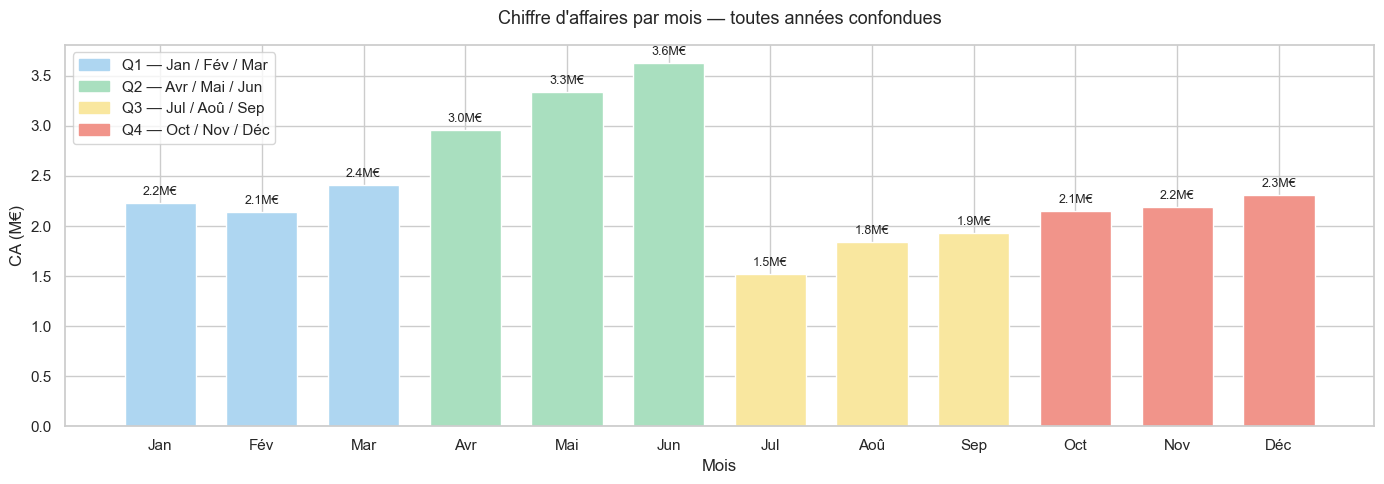

In [96]:
print("\n====== CHIFFRE D'AFFAIRES PAR MOIS — toutes années confondues ======")

from matplotlib.patches import Patch

ca_par_mois = (
    transactions_clean.groupby(transactions_clean["invoice_date"].dt.month)["line_total"]
    .sum()
    .reset_index()
    .rename(columns={"invoice_date": "mois", "line_total": "ca"})
)

noms_mois = ["Jan", "Fév", "Mar", "Avr", "Mai", "Jun", "Jul", "Aoû", "Sep", "Oct", "Nov", "Déc"]
ca_par_mois["nom_mois"] = ca_par_mois["mois"].apply(lambda m: noms_mois[m - 1])

couleurs_saisons = {
    1: "#AED6F1", 2: "#AED6F1", 3: "#AED6F1",
    4: "#A9DFBF", 5: "#A9DFBF", 6: "#A9DFBF",
    7: "#F9E79F", 8: "#F9E79F", 9: "#F9E79F",
    10: "#F1948A", 11: "#F1948A", 12: "#F1948A"
}
couleurs = ca_par_mois["mois"].map(couleurs_saisons)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(ca_par_mois["nom_mois"], ca_par_mois["ca"] / 1e6, color=couleurs, edgecolor="white", width=0.7)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{bar.get_height():.1f}M€", ha="center", va="bottom", fontsize=9)

legende = [
    Patch(color="#AED6F1", label="Q1 — Jan / Fév / Mar"),
    Patch(color="#A9DFBF", label="Q2 — Avr / Mai / Jun"),
    Patch(color="#F9E79F", label="Q3 — Jul / Aoû / Sep"),
    Patch(color="#F1948A", label="Q4 — Oct / Nov / Déc"),
]
ax.legend(handles=legende, loc="upper left")
ax.set_title("Chiffre d'affaires par mois — toutes années confondues", fontsize=13, pad=15)
ax.set_xlabel("Mois")
ax.set_ylabel("CA (M€)")

plt.tight_layout()
plt.show()

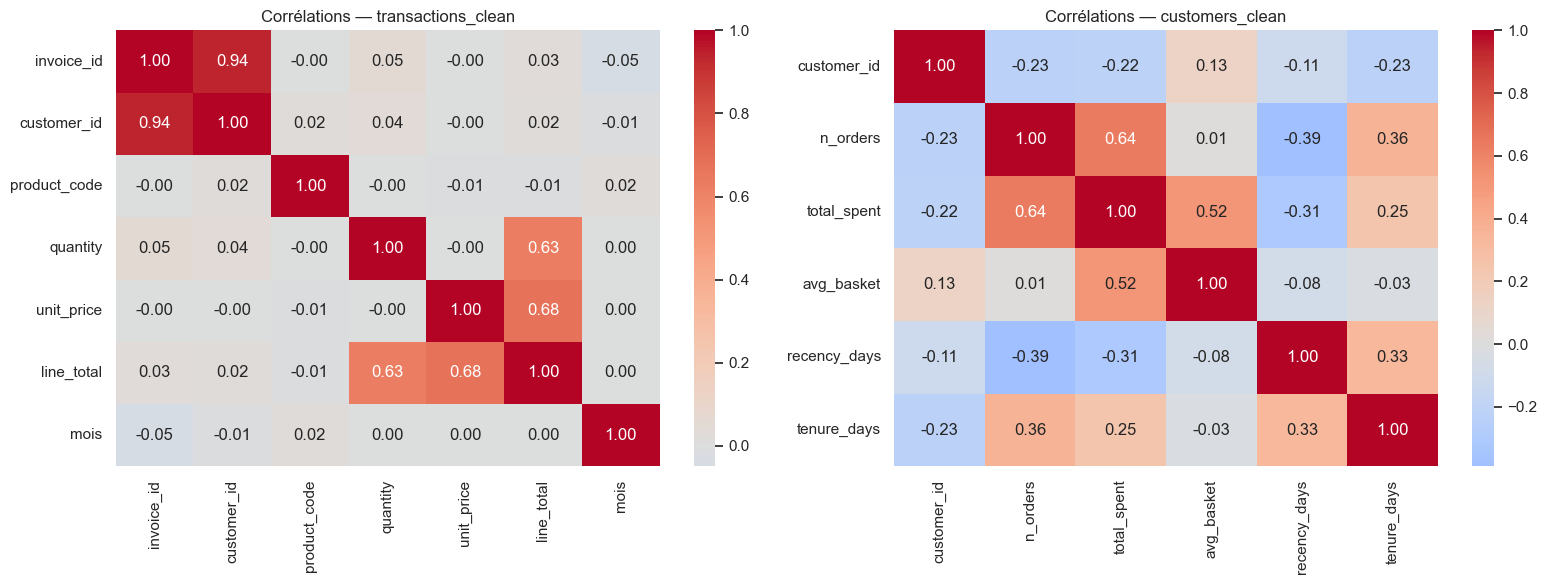

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap transactions_clean
corr_transactions = transactions_clean.select_dtypes(include="number").corr().round(2)
sns.heatmap(corr_transactions, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=axes[0])
axes[0].set_title("Corrélations — transactions_clean")

# Heatmap customers_clean
corr_customers = customers_clean.select_dtypes(include="number").corr().round(2)
sns.heatmap(corr_customers, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=axes[1])
axes[1].set_title("Corrélations — customers_clean")

plt.tight_layout()
plt.show()